# CNN Heart Sound Classification

**Feature input:** MFCC (13 coefficients)  
**Dataset:** Yaseen Khan 5-class heart sound dataset

## GPU Setup

In [3]:
import os
import tensorflow as tf

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU Memory Growth Enabled for: {physical_devices}')
    except RuntimeError as e:
        print(f'GPU Error: {e}')
else:
    print('No GPU detected. Running on CPU.')


GPU Memory Growth Enabled for: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Foundation Set Up and Configuration

In [5]:
import os
import numpy as np
import librosa
import librosa.display
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import warnings
from cryptography.utils import CryptographyDeprecationWarning

warnings.filterwarnings('ignore', category=CryptographyDeprecationWarning)
np.random.seed(42)
print('Libraries imported successfully!')

# --- CONFIGURATION (Yaseen Khan Dataset) ---
BASE_PATH = r'C:\Users\emirh\Downloads\FYP2\Models_Yaseen\Classification-of-Heart-Sound\HeartData'

# Yaseen Khan Dataset — 5 class folders inside HeartData
# Each folder name maps to one heart sound class:
#   N_New_3주기   -> Normal
#   MVP_New_3주기 -> Mitral Valve Prolapse
#   MS_New_3주기  -> Mitral Stenosis
#   MR_New_3주기  -> Mitral Regurgitation
#   AS_New_3주기  -> Aortic Stenosis
FOLDERS = [
    "N_New_3\uc8fc\uae30",    # Normal
    "MVP_New_3\uc8fc\uae30",  # Mitral Valve Prolapse
    "MS_New_3\uc8fc\uae30",   # Mitral Stenosis
    "MR_New_3\uc8fc\uae30",   # Mitral Regurgitation
    "AS_New_3\uc8fc\uae30"    # Aortic Stenosis
]

# Label mapping (integer -> class name)
CLASS_NAMES = {
    0: 'Normal',
    1: 'MVP',
    2: 'MS',
    3: 'MR',
    4: 'AS'
}

# Folder name -> integer label
FOLDER_LABEL_MAP = {
    "N_New_3\uc8fc\uae30": 0,
    "MVP_New_3\uc8fc\uae30": 1,
    "MS_New_3\uc8fc\uae30": 2,
    "MR_New_3\uc8fc\uae30": 3,
    "AS_New_3\uc8fc\uae30": 4
}

SAMPLE_RATE = 16000
DURATION = 5
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

print(f'BASE_PATH : {BASE_PATH}')
print(f'FOLDERS   : {FOLDERS}')
print(f'Classes   : {list(CLASS_NAMES.values())}')
print(f'SAMPLE_RATE : {SAMPLE_RATE}')
print(f'DURATION    : {DURATION}s')


Libraries imported successfully!
BASE_PATH : C:\Users\emirh\Downloads\FYP2\Models_Yaseen\Classification-of-Heart-Sound\HeartData
FOLDERS   : ['N_New_3주기', 'MVP_New_3주기', 'MS_New_3주기', 'MR_New_3주기', 'AS_New_3주기']
Classes   : ['Normal', 'MVP', 'MS', 'MR', 'AS']
SAMPLE_RATE : 16000
DURATION    : 5s


## Data Augmentation Functions


In [7]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    """Generates the filter coefficients."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Applies the Bandpass Filter (25-400Hz)."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = signal.lfilter(b, a, data)
    return y

def fix_duration_segmentation(data):
    """
    Apply 5-Second Fixed Segmentation.
    - If shorter than 5s: Pad with zeros.
    - If longer than 5s: Truncate.
    """
    if len(data) > SAMPLES_PER_TRACK:
        return data[:SAMPLES_PER_TRACK]
    else:
        padding = SAMPLES_PER_TRACK - len(data)
        return np.pad(data, (0, padding), 'constant')

def z_score_normalize(data):
    """
    Applies Z-Score Normalization (Standardization).
    Result has Mean = 0, Std Dev = 1.
    """
    mean = np.mean(data)
    std = np.std(data)
    if std > 0:
        return (data - mean) / std
    else:
        return data

# AUGMENTATION FUNCTIONS
def add_noise_awgn(data):
   
    sigma = np.sqrt(np.mean(data ** 2))   # RMS of the signal
    noise = np.random.normal(0, sigma, len(data))
    return data + noise

def pitch_shift(data, sampling_rate):
    
    p = np.random.randint(1, 11)          # integer in [1, 10]
    direction = np.random.choice([-1, 1]) # up or down
    n_steps = direction * p
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

print('Preprocessing and augmentation functions defined.')


Preprocessing and augmentation functions defined.


## Feature Extraction (MFCC — 24×13)

In [9]:
# MFCC configuration
N_MFCC         = 13
MFCC_TIME_STEPS = 24
N_FFT          = 2048
HOP_LENGTH     = 512

def extract_features(audio_data, sample_rate):
    
    mfcc = librosa.feature.mfcc(
        y=audio_data,
        sr=sample_rate,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # Pad or truncate along the time axis
    if mfcc.shape[1] < MFCC_TIME_STEPS:
        pad_width = MFCC_TIME_STEPS - mfcc.shape[1]
        mfcc = np.pad(
            mfcc,
            pad_width=((0, 0), (0, pad_width)),
            mode='constant'
        )
    else:
        mfcc = mfcc[:, :MFCC_TIME_STEPS]

    # Transpose to (time_steps, mfcc_features) = (24, 13)
    mfcc = mfcc.T

    return mfcc.astype(np.float32)

print('Feature extraction function defined (MFCC).')
print(f'Output shape per sample: ({MFCC_TIME_STEPS}, {N_MFCC})')


Feature extraction function defined (MFCC).
Output shape per sample: (24, 13)


## Data Preparation (Yaseen Khan Dataset — MFCC — Noise Injection + Pitch Shift Augmentation on Training Set)

In [11]:
from tensorflow.keras.utils import to_categorical
from collections import Counter


file_paths = []
labels = []

# Keep lower-case alias so the processing/evaluation cells remain consistent
class_names = CLASS_NAMES

print('Scanning Yaseen Khan folders...')
for folder_name, label in FOLDER_LABEL_MAP.items():
    folder_path = os.path.join(BASE_PATH, folder_name)

    if not os.path.exists(folder_path):
        print(f'  [WARNING] Folder not found: {folder_path}')
        continue

    for filename in os.listdir(folder_path):
        filename_lower = filename.lower()

        if not filename_lower.endswith('.wav'):
            continue

        file_path = os.path.join(folder_path, filename)
        file_paths.append(file_path)
        labels.append(label)

print(f'\nTotal valid files gathered: {len(labels)}')
distribution = Counter(labels)
print('-' * 35)
print('CLASS DISTRIBUTION (Before Split):')
for label_int in sorted(distribution.keys()):
    print(f' - [{label_int}] {class_names[label_int]:<12}: {distribution[label_int]} files')
print('-' * 35 + '\n')

# ============================================================
# 2. STRATIFIED SPLIT: 70 / 10 / 20
# ============================================================
X_train_val_paths, X_test_paths, y_train_val_labels, y_test_labels = train_test_split(
    file_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

X_train_paths, X_val_paths, y_train_labels, y_val_labels = train_test_split(
    X_train_val_paths, y_train_val_labels, test_size=0.125, stratify=y_train_val_labels, random_state=42
)

print(f'File Counts -> Train: {len(X_train_paths)}, Val: {len(X_val_paths)}, Test: {len(X_test_paths)}')


max_original_class_count = max(distribution.values()) if len(distribution) > 0 else 0
TARGET_COUNTS = {
    0: max_original_class_count,  # Normal
    1: max_original_class_count,  # MVP
    2: max_original_class_count,  # MS
    3: max_original_class_count,  # MR
    4: max_original_class_count   # AS
}

print('\nTARGET_COUNTS for training augmentation:')
for label_int in sorted(TARGET_COUNTS.keys()):
    print(f' - {class_names[label_int]:<12}: {TARGET_COUNTS[label_int]}')


Scanning Yaseen Khan folders...

Total valid files gathered: 1000
-----------------------------------
CLASS DISTRIBUTION (Before Split):
 - [0] Normal      : 200 files
 - [1] MVP         : 200 files
 - [2] MS          : 200 files
 - [3] MR          : 200 files
 - [4] AS          : 200 files
-----------------------------------

File Counts -> Train: 700, Val: 100, Test: 200

TARGET_COUNTS for training augmentation:
 - Normal      : 200
 - MVP         : 200
 - MS          : 200
 - MR          : 200
 - AS          : 200


### Processing Function

In [13]:
def process_data_with_augmentation(X_paths, y_labels, augment=False):
    X_mfccs = []
    y_final = []

    # Store original preprocessed audio for augmentation
    audio_by_class = {0: [], 1: [], 2: [], 3: [], 4: []}

    print(f'   Processing {len(X_paths)} files (Augment={augment})...')

    # ====================================================
    # STEP 1: Process original files
    # ====================================================
    for i, fpath in enumerate(X_paths):
        try:
            y, sr = librosa.load(fpath, sr=SAMPLE_RATE, duration=DURATION)

            y = butter_bandpass_filter(y, 25, 400, sr)
            y = fix_duration_segmentation(y)
            y = z_score_normalize(y)

            current_label = y_labels[i]

            mfcc = extract_features(y, sr)

            X_mfccs.append(mfcc)
            y_final.append(current_label)

            audio_by_class[current_label].append((y, sr))

        except Exception as e:
            print(f'[SKIPPED ORIGINAL] {fpath} -> {e}')

    # ====================================================
    # STEP 2: Combined target-count augmentation
    # Uses both:
    #   1. AWGN noise injection
    #   2. Random pitch shifting
    #
    # Augmentation alternates between noise injection and pitch shifting
    # until each class reaches its target count.
    # ====================================================
    if augment:
        print('\n   Applying combined augmentation: AWGN noise injection + pitch shifting...')

        current_distribution = Counter(y_final)

        for label in sorted(TARGET_COUNTS.keys()):
            current_count = current_distribution[label]
            target_count = TARGET_COUNTS[label]
            needed = target_count - current_count

            print(
                f'   {class_names[label]:<12}: '
                f'current={current_count}, target={target_count}, need={needed}'
            )

            if needed <= 0:
                continue

            if len(audio_by_class[label]) == 0:
                print(f'   No audio available for {class_names[label]}. Skipping.')
                continue

            added = 0
            audio_index = 0

            while added < needed:
                y_original, sr = audio_by_class[label][audio_index % len(audio_by_class[label])]

                try:
                    # Alternate augmentation type to use both methods
                    if added % 2 == 0:
                        y_aug = add_noise_awgn(y_original)
                    else:
                        y_aug = pitch_shift(y_original, sr)

                    mfcc_aug = extract_features(y_aug, sr)

                    X_mfccs.append(mfcc_aug)
                    y_final.append(label)

                    added += 1
                    audio_index += 1

                except Exception as e:
                    print(f'   [SKIPPED AUGMENTATION] {class_names[label]} -> {e}')
                    audio_index += 1

    return np.array(X_mfccs), np.array(y_final)


In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Combined AWGN noise injection and pitch-shift augmentation applied to training split only
print('Processing Training Data (AWGN Noise Injection + Pitch Shift Augmentation)...')
X_train_mfcc, y_train_indices = process_data_with_augmentation(
    X_train_paths, y_train_labels, augment=True
)

# Print post-augmentation distribution
aug_distribution = Counter(y_train_indices)
print('\n' + '=' * 45)
print('TRAINING DATA AFTER AWGN NOISE INJECTION + PITCH SHIFT AUGMENTATION (Yaseen Khan MFCC):')
for label_int in sorted(aug_distribution.keys()):
    print(f' - {class_names[label_int]:<12}: {aug_distribution[label_int]} files')
print('=' * 45 + '\n')

print('\nProcessing Validation Data (No Augmentation)...')
X_val_mfcc, y_val_indices = process_data_with_augmentation(
    X_val_paths, y_val_labels, augment=False
)

print('\nProcessing Test Data (No Augmentation)...')
X_test_mfcc, y_test_indices = process_data_with_augmentation(
    X_test_paths, y_test_labels, augment=False
)

# Float32 conversion
X_train_mfcc = X_train_mfcc.astype('float32')
X_val_mfcc   = X_val_mfcc.astype('float32')
X_test_mfcc  = X_test_mfcc.astype('float32')

# Add channel dimension for Conv2D CNN input.
# Shape changes from (N, 24, 13) to (N, 24, 13, 1),
# where 1 means a single-channel MFCC feature map.
if X_train_mfcc.ndim == 3:
    X_train_mfcc = np.expand_dims(X_train_mfcc, axis=-1)
if X_val_mfcc.ndim == 3:
    X_val_mfcc = np.expand_dims(X_val_mfcc, axis=-1)
if X_test_mfcc.ndim == 3:
    X_test_mfcc = np.expand_dims(X_test_mfcc, axis=-1)

# One-hot encoding (5 classes)
y_train = to_categorical(y_train_indices, num_classes=5)
y_val   = to_categorical(y_val_indices,   num_classes=5)
y_test  = to_categorical(y_test_indices,  num_classes=5)

y_train = y_train.astype('float32')
y_val   = y_val.astype('float32')
y_test  = y_test.astype('float32')

# Class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weights = dict(enumerate(class_weights_array))

print('--- FINAL ARRAYS READY ---')
print(f'CNN Input Shape (Train) : {X_train_mfcc.shape}')   # (N, 24, 13, 1)
print(f'CNN Input Shape (Val)   : {X_val_mfcc.shape}')
print(f'CNN Input Shape (Test)  : {X_test_mfcc.shape}')
print(f'Label Shape (Train)     : {y_train.shape}')

print('\nClass Weights:')
for k, v in class_weights.items():
    print(f'  [{k}] {class_names[k]:<12}: {v:.4f}')


Processing Training Data (AWGN Noise Injection + Pitch Shift Augmentation)...
   Processing 700 files (Augment=True)...

   Applying combined augmentation: AWGN noise injection + pitch shifting...
   Normal      : current=140, target=200, need=60
   MVP         : current=140, target=200, need=60
   MS          : current=140, target=200, need=60
   MR          : current=140, target=200, need=60
   AS          : current=140, target=200, need=60

TRAINING DATA AFTER AWGN NOISE INJECTION + PITCH SHIFT AUGMENTATION (Yaseen Khan MFCC):
 - Normal      : 200 files
 - MVP         : 200 files
 - MS          : 200 files
 - MR          : 200 files
 - AS          : 200 files


Processing Validation Data (No Augmentation)...
   Processing 100 files (Augment=False)...

Processing Test Data (No Augmentation)...
   Processing 200 files (Augment=False)...
--- FINAL ARRAYS READY ---
CNN Input Shape (Train) : (1000, 24, 13, 1)
CNN Input Shape (Val)   : (100, 24, 13, 1)
CNN Input Shape (Test)  : (200, 24, 

## Model Training — CNN Using Reference-Paper-Style Conv2D Architecture (Yaseen Khan Dataset — MFCC Input)

In [16]:
import gc
import math
import tensorflow as tf

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

# Clear memory
K.clear_session()
gc.collect()
print('Memory cleared.')

# Memory-safe generator 
class NumpyDataGenerator(Sequence):
    def __init__(self, X, y, batch_size=4, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.X) / self.batch_size)

    def __getitem__(self, index):
        batch_indices = self.indices[
            index * self.batch_size : (index + 1) * self.batch_size
        ]
        X_batch = self.X[batch_indices].astype('float32')
        y_batch = self.y[batch_indices].astype('float32')
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


BATCH_SIZE = 4

train_gen = NumpyDataGenerator(X_train_mfcc, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = NumpyDataGenerator(X_val_mfcc,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

print('Memory-safe generators created.')


model_cnn = Sequential(name='CNN_MFCC_YaseenKhan_ZhouCNN_5Class')

model_cnn.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=(1, 1),
    activation='relu',
    padding='valid',
    input_shape=(MFCC_TIME_STEPS, N_MFCC, 1)
))
model_cnn.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding='valid'
))

model_cnn.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    strides=(1, 1),
    activation='relu',
    padding='valid'
))
model_cnn.add(MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding='valid'
))

model_cnn.add(Flatten())

# Fully connected layer with 64 hidden units
model_cnn.add(Dense(64, activation='relu'))

# Output: 5 classes for Yaseen Khan classification
model_cnn.add(Dense(5, activation='softmax'))

# Compile 
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# Callbacks 
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

print('Training CNN-MFCC Model on Yaseen Khan Dataset...')

history = model_cnn.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=[early_stopper, reduce_lr],
    class_weight=class_weights
)


Memory cleared.
Memory-safe generators created.
Model: "CNN_MFCC_YaseenKhan_ZhouCNN_5Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 22, 11, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 5, 32)        0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 9, 3, 64)          18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 1, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 256)               0         
                                                  

In [17]:
import gc
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

model_path = 'cnn_mfcc_yaseenkhan_5class.h5'

print('Current directory:', os.getcwd())

model_cnn.save(model_path)
print('Model saved successfully!')

K.clear_session()
gc.collect()
print('Memory cleared after training.')

model_cnn = load_model(model_path)
print('Model reloaded successfully!')


Current directory: C:\Users\emirh\Downloads\FYP2\Models_Yaseen\MFCC_As_Input\CNN
Model saved successfully!
Memory cleared after training.
Model reloaded successfully!


## Training Curves

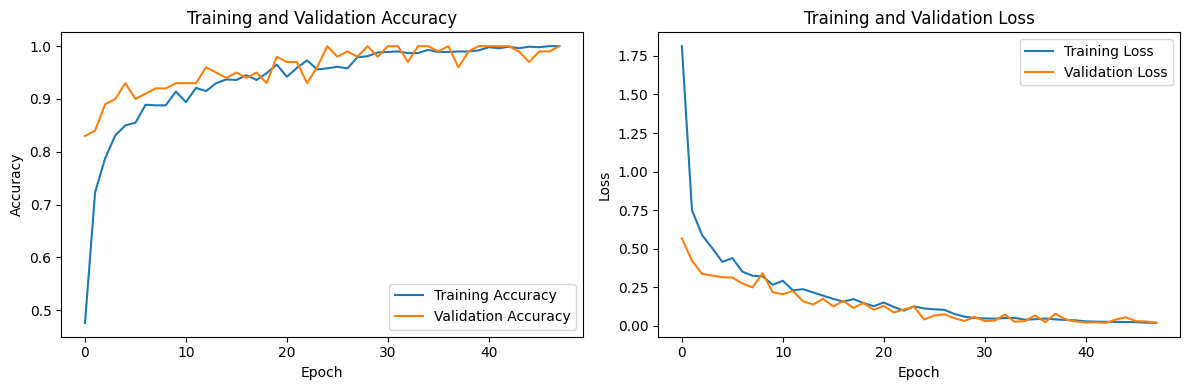

In [19]:
if 'history' in locals():
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No history found. Please train the model first.')


## Classification Output

> Evaluation function is kept the same as the CNN MelSpec Yaseen Khan notebook, with Yaseen Khan class labels.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Class labels for Yaseen Khan dataset
classes = ['Normal', 'MVP', 'MS', 'MR', 'AS']

def evaluate_and_plot_manual(model, X, y, set_name, batch_size=1):
    print(f"\n{'='*20} {set_name.upper()} RESULTS {'='*20}")

    y_true_all = []
    y_pred_all = []

    total_samples = len(X)

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)

        X_batch = X[start:end].astype('float32')
        y_batch = y[start:end]

        pred_batch = model.predict(X_batch, verbose=0)

        y_pred_all.extend(np.argmax(pred_batch, axis=1))
        y_true_all.extend(np.argmax(y_batch, axis=1))

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    acc = accuracy_score(y_true_all, y_pred_all)
    print(f'{set_name} Accuracy: {acc * 100:.2f}%')

    cm = confusion_matrix(y_true_all, y_pred_all)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(f'Confusion Matrix ({set_name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true_all,
        y_pred_all,
        target_names=classes,
        labels=[0, 1, 2, 3, 4],
        zero_division=0
    ))



==================== TRAINING SET RESULTS ====================
Training Set Accuracy: 99.90%


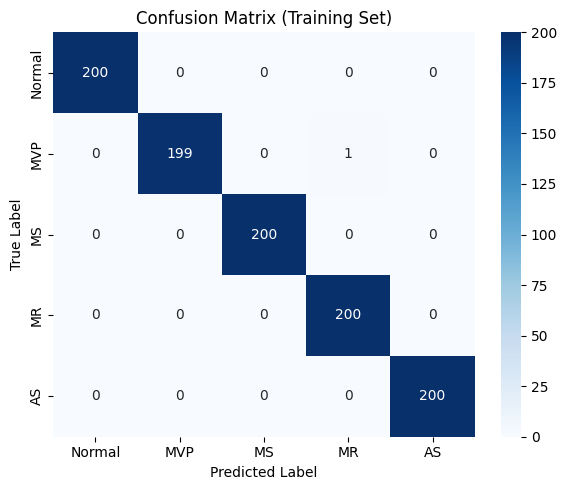

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       200
         MVP       1.00      0.99      1.00       200
          MS       1.00      1.00      1.00       200
          MR       1.00      1.00      1.00       200
          AS       1.00      1.00      1.00       200

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [22]:
evaluate_and_plot_manual(model_cnn, X_train_mfcc, y_train, 'Training Set', batch_size=4)


==================== VALIDATION SET RESULTS ====================
Validation Set Accuracy: 100.00%


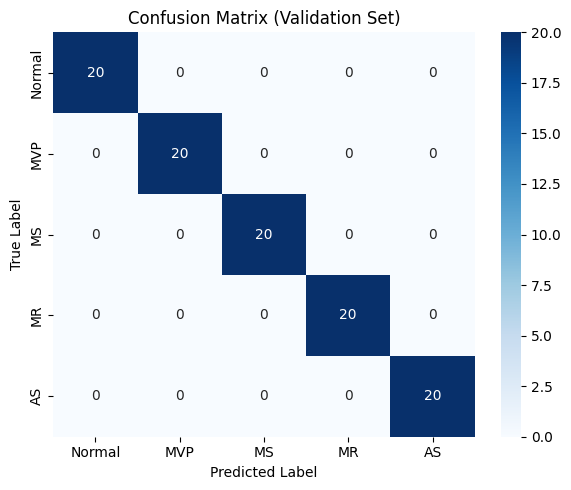

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        20
         MVP       1.00      1.00      1.00        20
          MS       1.00      1.00      1.00        20
          MR       1.00      1.00      1.00        20
          AS       1.00      1.00      1.00        20

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [23]:
evaluate_and_plot_manual(model_cnn, X_val_mfcc,   y_val,   'Validation Set', batch_size=4)


==================== TEST SET RESULTS ====================
Test Set Accuracy: 97.00%


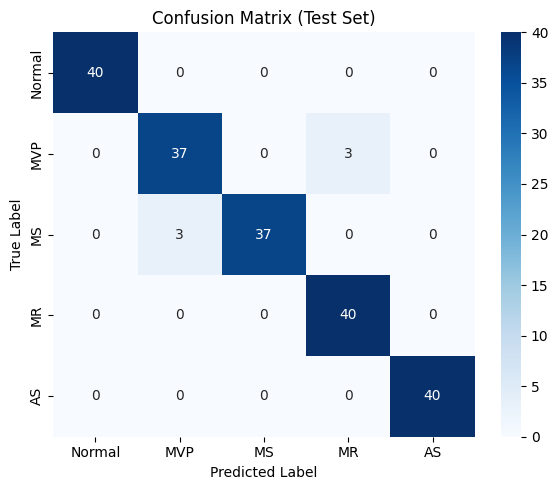

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        40
         MVP       0.93      0.93      0.93        40
          MS       1.00      0.93      0.96        40
          MR       0.93      1.00      0.96        40
          AS       1.00      1.00      1.00        40

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



In [24]:
evaluate_and_plot_manual(model_cnn, X_test_mfcc,  y_test,  'Test Set', batch_size=4)